# Statcast Pitch Data — Exploratory Data Analysis

Pull one full season of Statcast data via `pybaseball` and explore the features relevant to pitch classification.

**Goals**
- Understand the shape and quality of the data
- Identify missing values and decide how to handle them
- Profile the distribution of pitch types (supervised learning labels)
- Visualize ball-flight features that will drive both models
- Surface correlations and redundancies across the feature set

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pybaseball import statcast
from pybaseball import cache

cache.enable()  # cache Statcast downloads locally

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

## 2. Load Data

Pull one full MLB season. 2023 is a good baseline — full 162-game schedule, universal DH, post-shift-ban rules in effect.

In [2]:
df_raw = pd.read_parquet('../data/statcast_2023_raw.parquet')
print(f"Rows: {len(df_raw):,}  |  Columns: {df_raw.shape[1]}")
df_raw.head(3)

Rows: 720,684  |  Columns: 118


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,...,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2023-03-31,84.500,3.410,5.290,"Puk, A.J.",643446,640462,field_out,hit_into_play,<NA>,<NA>,<NA>,<NA>,13,"Jeff McNeil grounds out, second baseman Luis A...",R,L,L,MIA,NYM,X,4,ground_ball,0,2,2023,-0.970,0.540,-0.535,...,0.022,-0.169,<NA>,<NA>,0.068,0.169,88.000,1,-1,0.978,0.022,28,31,28,31,1,3,<NA>,1,5,1,2.650,-0.970,-0.970,25.900,<NA>,<NA>,<NA>,<NA>,<NA>
1,ST,2023-03-31,84.100,3.400,5.380,"Puk, A.J.",643446,640462,NaN,foul,<NA>,<NA>,<NA>,<NA>,7,NaN,R,L,L,MIA,NYM,S,<NA>,NaN,0,1,2023,-1.380,0.400,-0.706,...,0.009,-0.061,<NA>,<NA>,<NA>,0.061,88.000,1,-1,0.969,0.031,28,31,28,31,1,3,<NA>,1,5,1,2.850,-1.380,-1.380,27.400,<NA>,<NA>,<NA>,<NA>,<NA>
2,ST,2023-03-31,83.700,3.390,5.320,"Puk, A.J.",643446,640462,NaN,foul,<NA>,<NA>,<NA>,<NA>,9,NaN,R,L,L,MIA,NYM,S,<NA>,NaN,0,0,2023,-1.350,0.520,0.784,...,0.006,-0.045,<NA>,<NA>,<NA>,0.045,94.800,1,-1,0.963,0.037,28,31,28,31,1,3,<NA>,1,5,1,2.780,-1.350,-1.350,26.200,<NA>,<NA>,<NA>,<NA>,<NA>


## 3. Column Overview

In [3]:
# All columns and dtypes
pd.DataFrame({'dtype': df_raw.dtypes, 'null_pct': df_raw.isnull().mean().mul(100).round(2)})

,dtype,null_pct
pitch_type,str,0.420
game_date,str,0.000
release_speed,Float64,0.390
release_pos_x,Float64,0.400
release_pos_z,Float64,0.400
...,...,...
attack_angle,Float64,79.980
attack_direction,Float64,79.980
swing_path_tilt,Float64,79.980
intercept_ball_minus_batter_pos_x_inches,Float64,80.000


In [4]:
# Candidate ball-flight features for modeling
BALL_FLIGHT_FEATURES = [
    'release_speed',       # velocity out of hand
    'effective_speed',     # perceived velocity at plate
    'release_spin_rate',   # spin rate (RPM)
    'spin_axis',           # spin axis (degrees)
    'pfx_x',               # horizontal break (inches, catcher's POV)
    'pfx_z',               # vertical break (induced, inches)
    'plate_x',             # horizontal location at plate
    'plate_z',             # vertical location at plate
    'release_pos_x',       # release point X
    'release_pos_y',       # release point Y (distance from mound)
    'release_pos_z',       # release point Z (height)
    'release_extension',   # extension toward plate
    'vx0', 'vy0', 'vz0',   # velocity components at release
    'ax', 'ay', 'az',      # acceleration components
]

print(f"{len(BALL_FLIGHT_FEATURES)} candidate features")
df_raw[BALL_FLIGHT_FEATURES].describe()

18 candidate features


,release_speed,effective_speed,release_spin_rate,spin_axis,pfx_x,pfx_z,plate_x,plate_z,release_pos_x,release_pos_y,release_pos_z,release_extension,vx0,vy0,vz0,ax,ay,az
count,717838.000,716603.000,713765.000,713765.000,717835.000,717835.000,717673.000,717673.000,717835.000,717835.000,717835.000,716775.000,717835.000,717835.000,717835.000,717835.000,717835.000,717835.000
mean,88.999,89.249,2249.147,175.705,-0.125,0.590,0.036,2.282,-0.860,54.061,5.772,6.439,2.525,-129.450,-3.772,-2.344,26.875,-24.140
std,6.110,6.286,339.211,72.962,0.894,0.711,0.833,0.969,1.827,0.466,0.541,0.467,5.697,8.849,3.007,10.807,3.990,8.684
min,33.400,29.200,16.000,0.000,-2.580,-2.140,-11.365,-4.277,-4.850,48.760,0.760,3.000,-20.927,-152.332,-20.160,-30.287,1.685,-51.284
25%,84.600,84.800,2099.000,129.000,-0.890,0.140,-0.525,1.649,-2.140,53.750,5.490,6.100,-1.431,-136.558,-5.795,-11.533,23.909,-30.385
50%,89.800,90.100,2276.000,200.000,-0.190,0.640,0.033,2.289,-1.530,54.050,5.810,6.400,4.105,-130.634,-3.848,-2.295,26.732,-24.352
75%,93.900,94.200,2448.000,223.000,0.580,1.200,0.592,2.923,0.750,54.370,6.100,6.700,6.616,-123.085,-1.842,5.961,29.822,-16.518
max,104.800,105.700,3544.000,360.000,2.360,2.840,5.689,11.024,4.740,57.490,8.110,11.700,21.484,-44.517,15.707,31.448,45.494,2.964


## 4. Missing Value Analysis

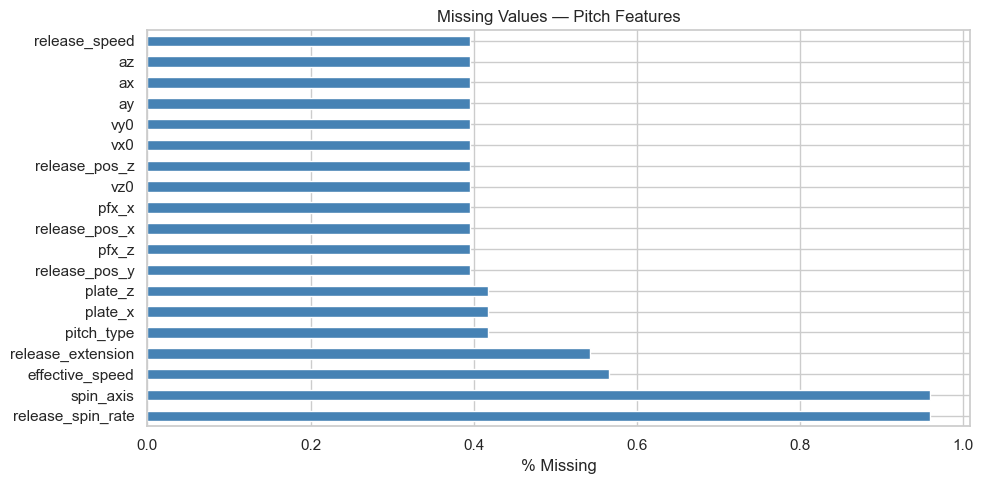

release_spin_rate   0.960
spin_axis           0.960
effective_speed     0.566
release_extension   0.542
pitch_type          0.418
plate_x             0.418
plate_z             0.418
release_pos_y       0.395
pfx_z               0.395
release_pos_x       0.395
pfx_x               0.395
vz0                 0.395
release_pos_z       0.395
vx0                 0.395
vy0                 0.395
ay                  0.395
ax                  0.395
az                  0.395
release_speed       0.395


In [5]:
missing = df_raw[['pitch_type'] + BALL_FLIGHT_FEATURES].isnull().mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing[missing > 0].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values — Pitch Features')
plt.tight_layout()
plt.show()

print(missing[missing > 0].to_string())

## 5. Pitch Type Distribution

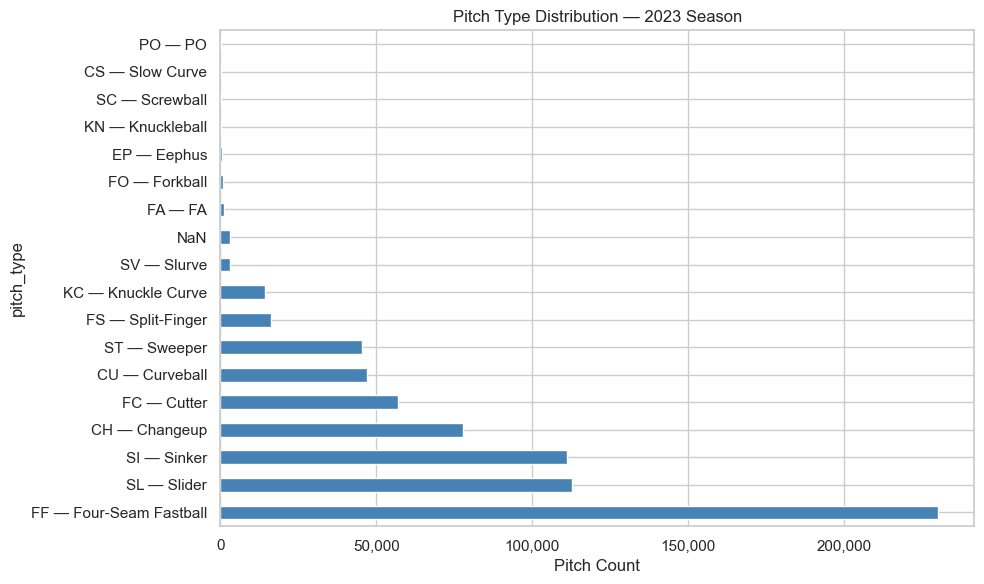

,count,pct
pitch_type,,
FF,230207,32.080
SL,112796,15.720
SI,111245,15.500
CH,77857,10.850
FC,56943,7.930
CU,46955,6.540
ST,45424,6.330
FS,16130,2.250
KC,14207,1.980


In [6]:
# Statcast pitch type codes and their names
PITCH_TYPE_MAP = {
    'FF': 'Four-Seam Fastball',
    'SI': 'Sinker',
    'FC': 'Cutter',
    'SL': 'Slider',
    'CU': 'Curveball',
    'CH': 'Changeup',
    'FS': 'Split-Finger',
    'ST': 'Sweeper',
    'SV': 'Slurve',
    'KC': 'Knuckle Curve',
    'KN': 'Knuckleball',
    'EP': 'Eephus',
    'FO': 'Forkball',
    'SC': 'Screwball',
    'CS': 'Slow Curve',
}

counts = df_raw['pitch_type'].value_counts(dropna=False)
counts.index = counts.index.map(lambda x: f"{x} — {PITCH_TYPE_MAP.get(x, x)}" if pd.notna(x) else 'NaN')

fig, ax = plt.subplots(figsize=(10, 6))
counts.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Pitch Count')
ax.set_title('Pitch Type Distribution — 2023 Season')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

pct = df_raw['pitch_type'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'count': df_raw['pitch_type'].value_counts(), 'pct': pct})

## 6. Filter to Pitches Used in Modeling

Drop rows with missing pitch type or missing core features, and restrict to pitch types with enough samples to model.

In [7]:
MIN_SAMPLES = 1000  # drop pitch types too rare to model reliably

valid_types = df_raw['pitch_type'].value_counts()
valid_types = valid_types[valid_types >= MIN_SAMPLES].index.tolist()
print(f"Pitch types with >= {MIN_SAMPLES} samples: {valid_types}")

df = (
    df_raw
    .loc[df_raw['pitch_type'].isin(valid_types)]
    .dropna(subset=BALL_FLIGHT_FEATURES)
    .reset_index(drop=True)
)

print(f"\nFiltered dataset: {len(df):,} rows  ({len(df)/len(df_raw)*100:.1f}% of raw)")
print(f"Pitch types retained: {df['pitch_type'].nunique()}")

Pitch types with >= 1000 samples: ['FF', 'SL', 'SI', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV', 'FA']

Filtered dataset: 711,447 rows  (98.7% of raw)
Pitch types retained: 11


## 7. Feature Distributions by Pitch Type

Violin plots for the four most discriminating features.

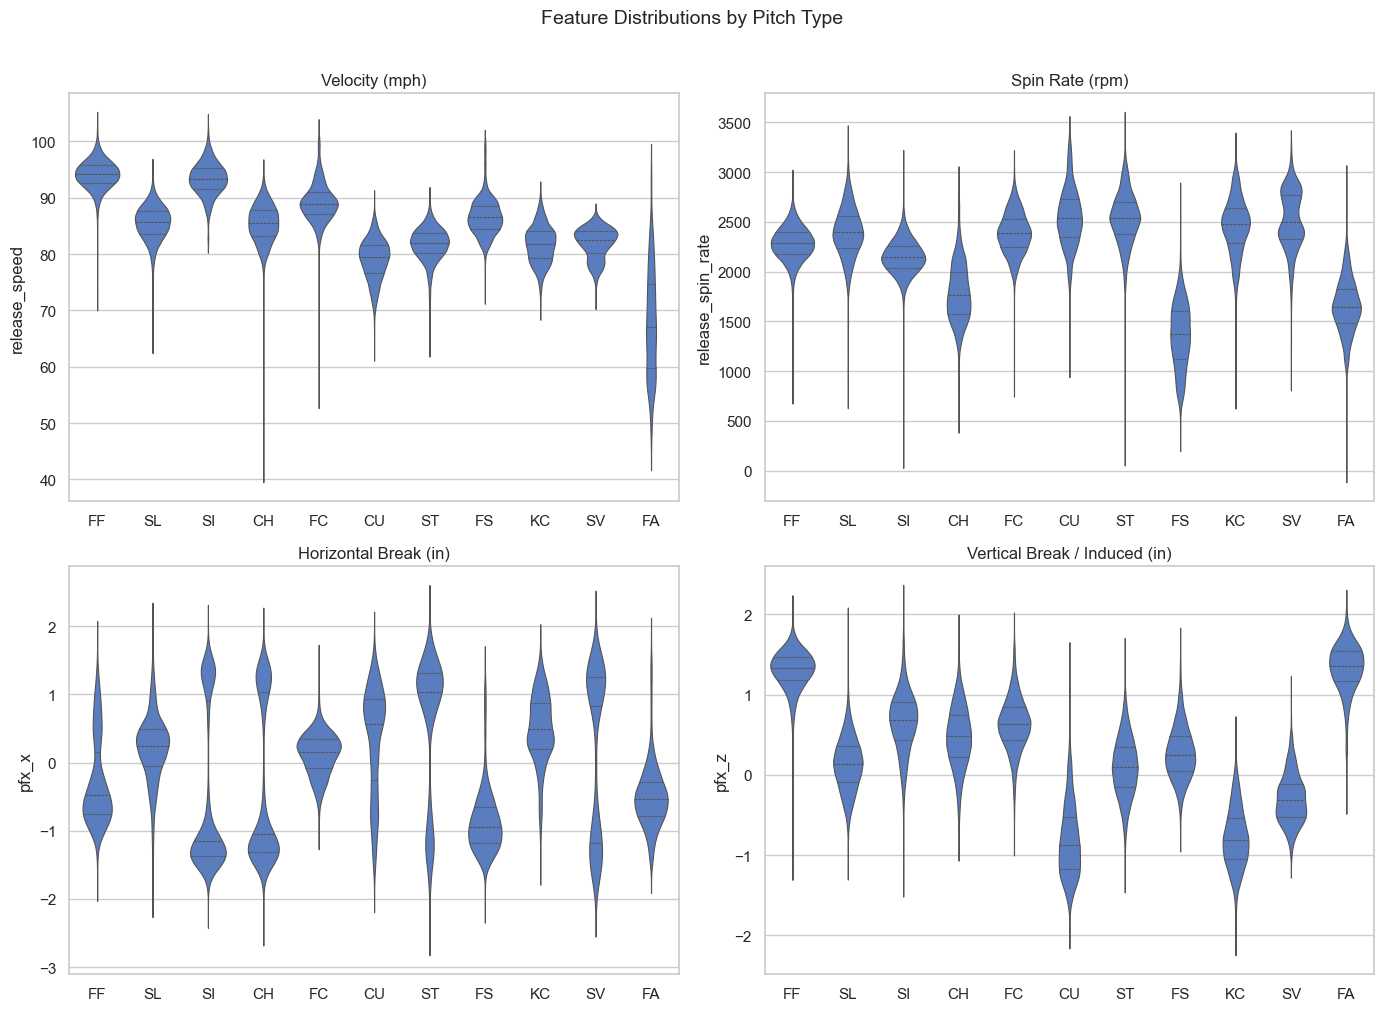

In [8]:
KEY_FEATURES = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z']
FEATURE_LABELS = {
    'release_speed': 'Velocity (mph)',
    'release_spin_rate': 'Spin Rate (rpm)',
    'pfx_x': 'Horizontal Break (in)',
    'pfx_z': 'Vertical Break / Induced (in)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

order = df['pitch_type'].value_counts().index.tolist()

for ax, feat in zip(axes, KEY_FEATURES):
    sns.violinplot(
        data=df, x='pitch_type', y=feat,
        order=order, ax=ax, inner='quartile', linewidth=0.8
    )
    ax.set_title(FEATURE_LABELS[feat])
    ax.set_xlabel('')

fig.suptitle('Feature Distributions by Pitch Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Movement Profile (Break Chart)

KeyError: 'pitch_type'

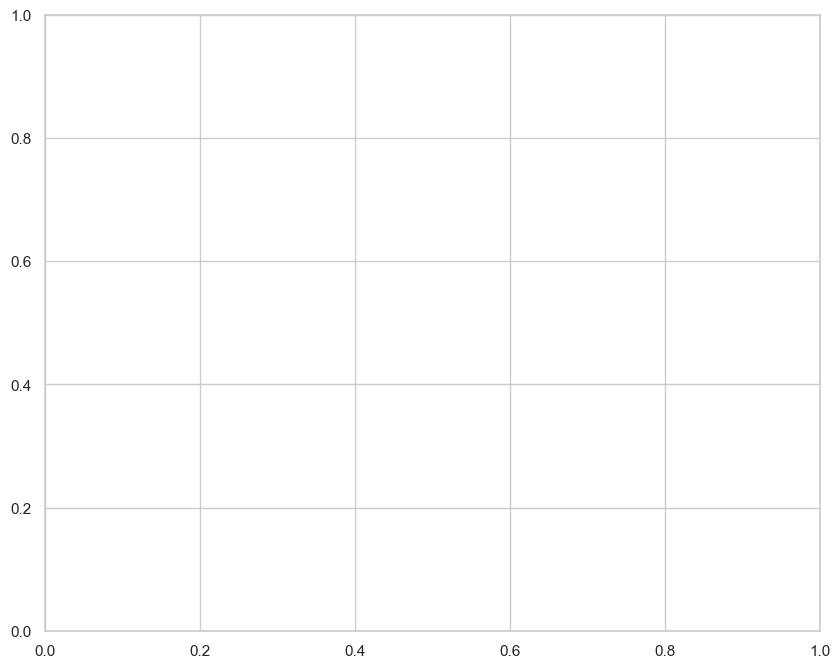

In [9]:
# Sample for plotting to avoid overplotting
sample = df.groupby('pitch_type', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 2000), random_state=SEED)
)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('tab10', n_colors=df['pitch_type'].nunique())

for i, pt in enumerate(order):
    sub = sample[sample['pitch_type'] == pt]
    ax.scatter(sub['pfx_x'], sub['pfx_z'], label=pt, alpha=0.25, s=8, color=palette[i])

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Horizontal Break (in)  ←Arm Side | Glove Side→')
ax.set_ylabel('Vertical Break / Induced (in)')
ax.set_title('Pitch Movement Profile — 2023 Season')
ax.legend(title='Pitch Type', bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=3)
plt.tight_layout()
plt.show()

## 9. Release Point by Pitch Type

KeyError: 'pitch_type'

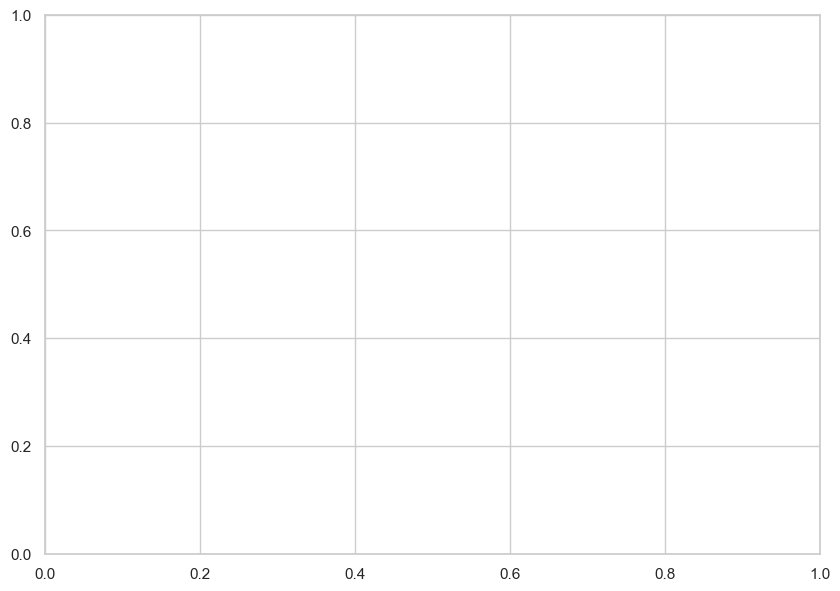

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, pt in enumerate(order):
    sub = sample[sample['pitch_type'] == pt]
    ax.scatter(sub['release_pos_x'], sub['release_pos_z'], label=pt, alpha=0.2, s=8, color=palette[i])

ax.set_xlabel('Release Position X (ft)')
ax.set_ylabel('Release Position Z — Height (ft)')
ax.set_title('Release Point by Pitch Type')
ax.legend(title='Pitch Type', bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=3)
plt.tight_layout()
plt.show()

## 10. Correlation Matrix

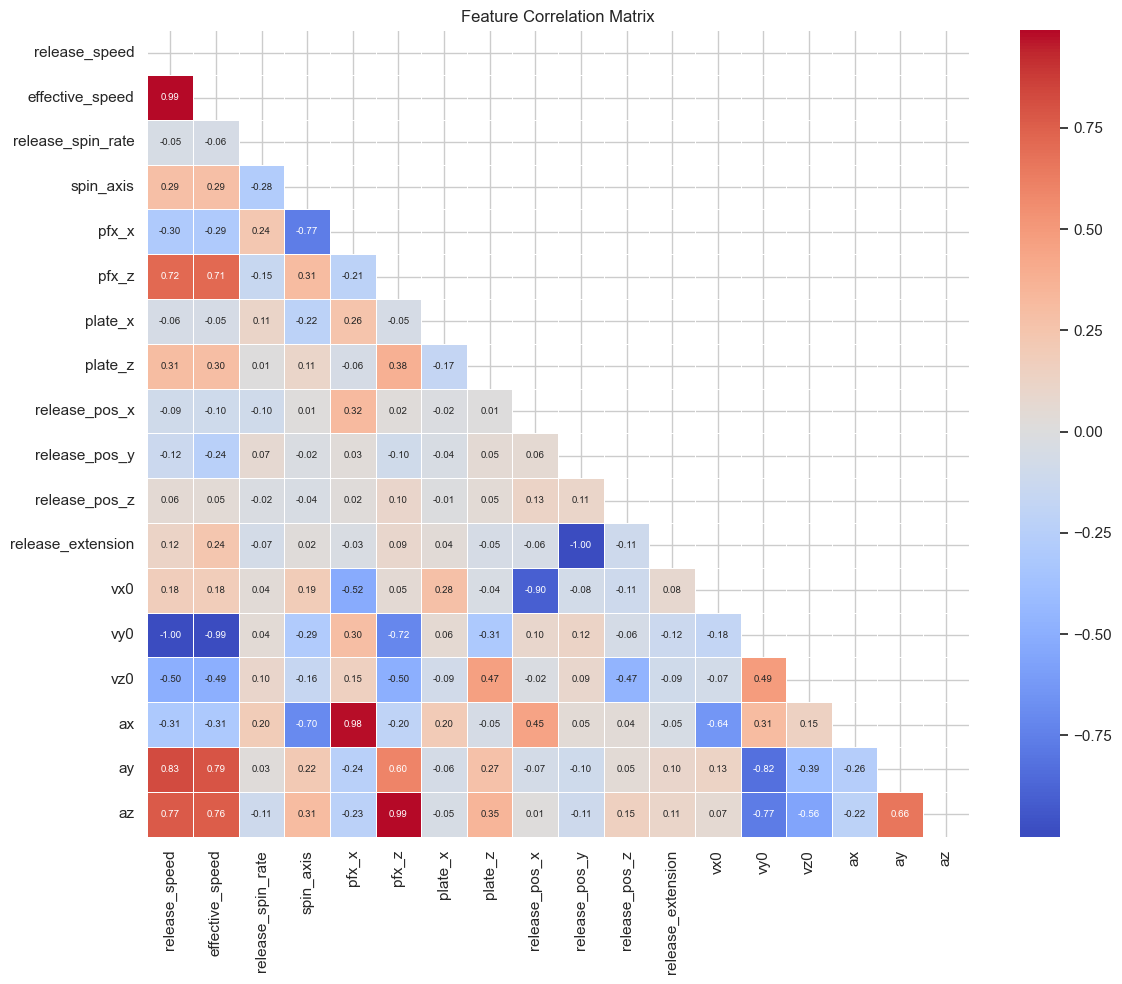

In [11]:
corr = df[BALL_FLIGHT_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 11. Class Balance Check

Important for supervised modeling — heavily imbalanced classes may need resampling or class weighting.

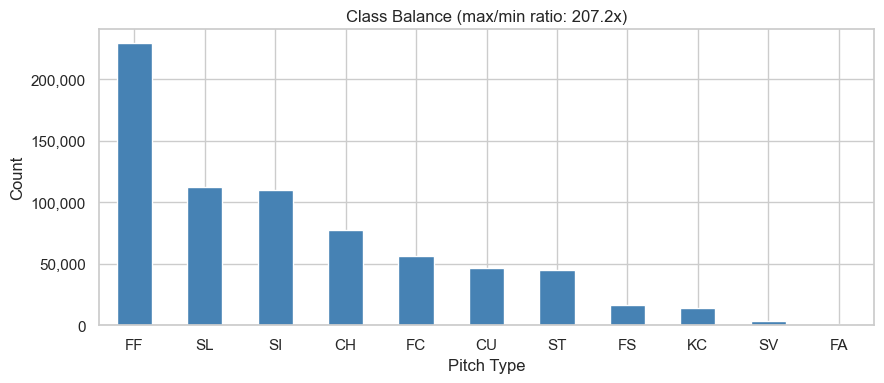

pitch_type
FF    229000
SL    112083
SI    110273
CH     77445
FC     56604
CU     46692
ST     45031
FS     16026
KC     14149
SV      3039
FA      1105


In [12]:
class_counts = df['pitch_type'].value_counts()
ratio = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(9, 4))
class_counts.plot.bar(ax=ax, color='steelblue')
ax.set_xlabel('Pitch Type')
ax.set_ylabel('Count')
ax.set_title(f'Class Balance (max/min ratio: {ratio:.1f}x)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(class_counts.to_string())

## 12. Save Cleaned Dataset

In [13]:
import os
os.makedirs('../data', exist_ok=True)

cols_to_save = ['pitch_type', 'player_name', 'game_date', 'p_throws'] + BALL_FLIGHT_FEATURES
df[cols_to_save].to_parquet('../data/statcast_2023_cleaned.parquet', index=False)
print(f"Saved {len(df):,} rows to data/statcast_2023_cleaned.parquet")

Saved 711,447 rows to data/statcast_2023_cleaned.parquet


## Summary — 2023 Statcast Season

| Item | Finding |
|------|---------|
| Raw rows | 720,684 |
| Rows after cleaning | 711,447 (dropped 9,237 — ~1.3%) |
| Columns | 118 |
| Pitch types retained (≥ 1k samples) | 11: FF, SL, SI, CH, FC, CU, ST, FS, KC, SV, FA |
| Pitch types dropped | CS, EP, FO, KN, PO, SC (all < 1k samples) |
| Missing values | All ball-flight features < 1% missing (max: spin_rate / spin_axis at 0.96%) |
| Most common pitch | FF — Four-Seam Fastball (229,000 pitches, 32.2%) |
| Least common pitch | FA — Generic Fastball (1,105 pitches, 0.2%) |
| Class imbalance ratio | 207x (FF vs FA) — heavy imbalance; consider class weights or dropping FA |
| Velocity range | 40.2 – 104.8 mph (mean 89.1 mph) |
| Spin rate range | 16 – 3,544 RPM (mean 2,252 RPM) |
| Horizontal break (pfx_x) | –2.58 to 2.36 in (mean –0.12 in) |
| Vertical break (pfx_z) | –2.14 to 2.29 in (mean 0.59 in) |

**Next steps**
- Decide whether to merge `FA` into `FF` or drop it given 207x imbalance
- Consider splitting by pitcher handedness (LHP vs RHP) — movement profiles mirror across arms
- Decide on final feature set: movement-only vs velocity+movement vs full ball-flight
- Assess whether class imbalance warrants SMOTE or class weights in the supervised model